In [1]:
# Cell 1: Setup, Drive mount, GPU check
# =====================================================================
import pandas as pd
import numpy as np
import glob
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount('/content/drive')
    except ValueError as e:
        print(f"Error mounting Google Drive: {e}. Please ensure you authorize access when prompted.")
    data_path = '/content/drive/MyDrive/f1-telemetry-ml'
else:
    data_path = '../fastf1_data/'

labeled_path = f'{data_path}/labeled'
processed_path = f'{data_path}/processed'


Using device: cpu


In [3]:

target_cols = ['aggression_score', 'line_shape_score', 'oversteer_preference_score']
SAFE_COLUMNS = ['Throttle', 'Brake', 'Speed', 'nGear', 'RPM']
MAX_SEQ_LEN = 30   # Median corner sequence length is ~21 samples, 75th pct ~25 —
                   # 30 avoids excessive zero-padding while covering most corners.
merge_keys = ['year', 'race', 'session_type', 'driver', 'lap_number', 'corner_number']

In [4]:
# Cell 2: Load the pre-split label files (train/val/test_in_dist/test_zero_shot)
# and all segmented telemetry
# =====================================================================
train_labels = pd.read_parquet(f'{labeled_path}/train_data.parquet')
val_labels = pd.read_parquet(f'{labeled_path}/val_data.parquet')
test_in_dist_labels = pd.read_parquet(f'{labeled_path}/test_in_dist_data.parquet')
test_zero_shot_labels = pd.read_parquet(f'{labeled_path}/test_zero_shot.parquet')

segmented_files = glob.glob(f'{processed_path}/corners_*.parquet')
segmented = pd.concat([pd.read_parquet(f) for f in segmented_files], ignore_index=True)
print(f"Segmented telemetry: {segmented.shape}")

Segmented telemetry: (6690826, 16)


In [5]:
# Cell 3: Build sequences for each split (vectorized merge, not row-by-row)
# =====================================================================
def build_sequences(labels_df, segmented_df):
    merged = segmented_df.merge(labels_df[merge_keys + target_cols], on=merge_keys, how='inner')
    grouped = merged.groupby(merge_keys)

    sequences, targets = [], []
    for _, group in grouped:
        group = group.sort_values('Distance')
        seq = group[SAFE_COLUMNS].to_numpy(dtype=np.float64)
        if len(seq) >= MAX_SEQ_LEN:
            seq = seq[:MAX_SEQ_LEN]
        else:
            pad = np.zeros((MAX_SEQ_LEN - len(seq), len(SAFE_COLUMNS)))
            seq = np.vstack([seq, pad])
        sequences.append(seq)
        targets.append(group[target_cols].iloc[0].values)

    return np.array(sequences), np.array(targets, dtype=np.float64)

print("Building sequences for all splits (this takes a few minutes)...")
t0 = time.time()
X_train, y_train = build_sequences(train_labels, segmented)
X_val, y_val = build_sequences(val_labels, segmented)
X_test_in_dist, y_test_in_dist = build_sequences(test_in_dist_labels, segmented)
X_test_zero_shot, y_test_zero_shot = build_sequences(test_zero_shot_labels, segmented)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Test (in-dist): {X_test_in_dist.shape}, Test (zero-shot): {X_test_zero_shot.shape}")

Building sequences for all splits (this takes a few minutes)...
Done in 86.7s
Train: (73848, 30, 5), Val: (32350, 30, 5)
Test (in-dist): (4152, 30, 5), Test (zero-shot): (35901, 30, 5)


In [6]:
# Cell 4: Scale (fit on TRAIN only, apply to all other splits)
# =====================================================================
n_train, seq_len, n_feat = X_train.shape
flat_train = X_train.reshape(-1, n_feat)
mean = flat_train.mean(axis=0)
std = flat_train.std(axis=0)
std[std == 0] = 1e-8

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test_in_dist = (X_test_in_dist - mean) / std
X_test_zero_shot = (X_test_zero_shot - mean) / std

In [7]:
# Cell 5: Dataset, model, training loop (GPU + training curve tracking)
# =====================================================================
class CornerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(CornerDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(CornerDataset(X_val, y_val), batch_size=32)


class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=32, n_outputs=3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, n_outputs)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])


model = LSTMRegressor(n_features=len(SAFE_COLUMNS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 35
train_losses, val_losses = [], []

train_start = time.time()
for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)
    avg_train_loss = total_train_loss / len(train_loader.dataset)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_val_loss += loss.item() * xb.size(0)
    avg_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{n_epochs} — train MSE: {avg_train_loss:.4f}, val MSE: {avg_val_loss:.4f}")

train_time = time.time() - train_start
print(f"\nTraining completed in {train_time:.1f}s on {device}")

Epoch 1/35 — train MSE: 0.0094, val MSE: 0.0070
Epoch 2/35 — train MSE: 0.0042, val MSE: 0.0056
Epoch 3/35 — train MSE: 0.0037, val MSE: 0.0059
Epoch 4/35 — train MSE: 0.0033, val MSE: 0.0049
Epoch 5/35 — train MSE: 0.0030, val MSE: 0.0051
Epoch 6/35 — train MSE: 0.0028, val MSE: 0.0046
Epoch 7/35 — train MSE: 0.0026, val MSE: 0.0043
Epoch 8/35 — train MSE: 0.0025, val MSE: 0.0042
Epoch 9/35 — train MSE: 0.0025, val MSE: 0.0052
Epoch 10/35 — train MSE: 0.0024, val MSE: 0.0043
Epoch 11/35 — train MSE: 0.0024, val MSE: 0.0041
Epoch 12/35 — train MSE: 0.0023, val MSE: 0.0041
Epoch 13/35 — train MSE: 0.0022, val MSE: 0.0041
Epoch 14/35 — train MSE: 0.0022, val MSE: 0.0041
Epoch 15/35 — train MSE: 0.0022, val MSE: 0.0039
Epoch 16/35 — train MSE: 0.0021, val MSE: 0.0042
Epoch 17/35 — train MSE: 0.0021, val MSE: 0.0041
Epoch 18/35 — train MSE: 0.0021, val MSE: 0.0050
Epoch 19/35 — train MSE: 0.0021, val MSE: 0.0040
Epoch 20/35 — train MSE: 0.0020, val MSE: 0.0037
Epoch 21/35 — train MSE: 0.00

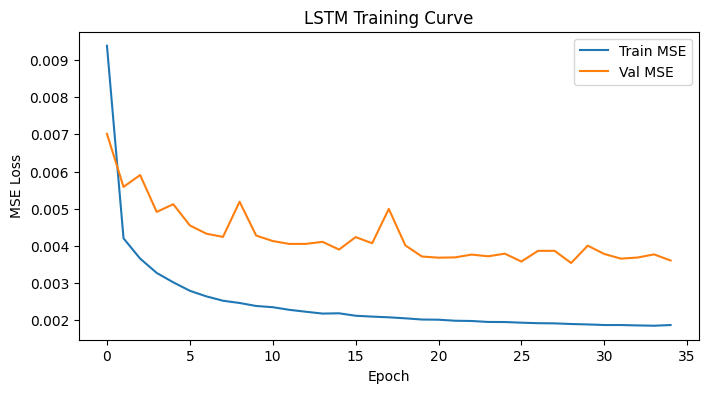

In [8]:
# Cell 6: Training curve plot (needed for the paper's Figure 1)
# =====================================================================
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training Curve')
plt.legend()
plt.show()

In [9]:
# Cell 7: Final evaluation on BOTH held-out test sets
# =====================================================================
model.eval()
for name, X_t, y_t in [("Test In-Distribution (Monza/Silverstone unseen laps)", X_test_in_dist, y_test_in_dist),
                         ("Test Zero-Shot (Belgium/Jeddah unseen tracks)", X_test_zero_shot, y_test_zero_shot)]:
    with torch.no_grad():
        preds = model(torch.tensor(X_t, dtype=torch.float32).to(device)).cpu().numpy()
    mae = mean_absolute_error(y_t, preds)
    rmse = mean_squared_error(y_t, preds) ** 0.5
    r2 = r2_score(y_t, preds)
    
    print(f"\n--- {name} ---")
    print(f"Overall MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}")
    
    for i, col in enumerate(target_cols):
        col_mae = mean_absolute_error(y_t[:, i], preds[:, i])
        col_rmse = mean_squared_error(y_t[:, i], preds[:, i]) ** 0.5
        col_r2 = r2_score(y_t[:, i], preds[:, i])
        print(f"  {col} — MAE: {col_mae:.4f}  RMSE: {col_rmse:.4f}  R2: {col_r2:.4f}")


--- Test In-Distribution (Monza/Silverstone unseen laps) ---
Overall MAE: 0.0244  RMSE: 0.0410  R2: 0.9446
  aggression_score — MAE: 0.0354  RMSE: 0.0608  R2: 0.8501
  line_shape_score — MAE: 0.0186  RMSE: 0.0261  R2: 0.9918
  oversteer_preference_score — MAE: 0.0191  RMSE: 0.0260  R2: 0.9918

--- Test Zero-Shot (Belgium/Jeddah unseen tracks) ---
Overall MAE: 0.0362  RMSE: 0.0637  R2: 0.9402
  aggression_score — MAE: 0.0414  RMSE: 0.0683  R2: 0.9016
  line_shape_score — MAE: 0.0329  RMSE: 0.0535  R2: 0.9646
  oversteer_preference_score — MAE: 0.0343  RMSE: 0.0681  R2: 0.9544


In [10]:
# Cell 8: Save model back to Drive
# =====================================================================
import os

if IN_COLAB:
    os.makedirs(f'{data_path}/models', exist_ok=True)
    torch.save(model.state_dict(), f'{data_path}/models/lstm_model.pt')
else:
    os.makedirs(f'../models', exist_ok=True)
    torch.save(model.state_dict(), f'../models/lstm_model.pt')
print("\nModel saved.")


Model saved.
